In [36]:
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(dplyr))
suppressMessages(library(ggplot2))
suppressMessages(library(future))
suppressMessages(library(parallel))
suppressMessages(library(RColorBrewer))
suppressMessages(library(viridis))
suppressMessages(library(qs))
suppressMessages(library(harmony))
suppressMessages(library(igraph))
suppressMessages(library(ggraph))
suppressMessages(library(ggrepel)) 
suppressMessages(library(tidyr))
suppressMessages(library(foreach))
suppressMessages(library(doParallel))
suppressMessages(library(tidygraph))
suppressMessages(library(anndata))
suppressMessages(library(randomForest))
suppressMessages(library(pheatmap))
suppressMessages(library(dbscan))
suppressMessages(library(scDblFinder))
suppressMessages(library(cowplot))

# Python 环境
suppressMessages(library(reticulate))
RETICULATE_PYTHON <- "/home/chaiqw/project/mb/.venv/bin/python"
use_virtualenv("/home/chaiqw/project/mb/.venv")

# 资源设定
plan("multicore", workers = 64)
options(future.globals.maxSize = 100000 * 1024^5)


In [37]:
DA = readRDS('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/20260728_VTA_DA_seurat_cluster.rds')
nonneuron = readRDS('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/20260729_VTA_nonneuron_cluster.rds')
neuron = readRDS('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/20260730_VTA_neuron.rds')

In [ ]:
merge_data <- merge(
    x = DA,
    y = list(nonneuron, neuron),
    add.cell.ids = c("DA", "nonneuron", "neuron"),
    project = "VTA_merged"
)

# 供后续 SCTransform 分析使用
seurat_1 <- merge_data

In [ ]:
seurat_1 = JoinLayers(seurat_1)

In [ ]:
SCTseurat = SCTransform(
    seurat_1, assay="RNA",
    ncells=ncol(seurat_1[["RNA"]]),
    variable.features.n=3000,
    vars.to.regress="percent.mt",
    return.only.var.genes = T,
    method="glmGamPoi"
)

SCTseurat = SCTseurat %>%
    RunPCA(npcs=100, verbose = FALSE) %>%
    FindNeighbors(dims = 1:30) %>%
    FindClusters(verbose = FALSE, resolution = 0.5, random.seed = 111) %>%
    RunUMAP(dims = 1:30,umap.method = "umap-learn"
)

# 去批次
SCTseurat_harmony = SCTseurat %>%
    RunHarmony(group.by.vars = c("Animal"),dims.use = 1:30 ,theta = 2,reduction = "pca", max.iter.harmony = 10,sigma = 0.1,assay.use = "SCT", reduction.save = "harmony") %>%
    # FindNeighbors(dims = 1:30, reduction = "harmony") %>%
    # FindClusters(verbose = FALSE, resolution =0.5, random.seed = 1234) %>%
    RunUMAP(dims = 1:30, reduction = "harmony", assay = "SCT"
)

Running SCTransform on assay: RNA



vst.flavor='v2' set. Using model with fixed slope and excluding poisson genes.

Calculating cell attributes from input UMI matrix: log_umi

Variance stabilizing transformation of count matrix of size 19243 by 81207

Model formula is y ~ log_umi

Get Negative Binomial regression parameters per gene

Using 2000 genes, 81207 cells

Found 23 outliers - those will be ignored in fitting/regularization step


Second step: Get residuals using fitted parameters for 19243 genes

Computing corrected count matrix for 19243 genes

Calculating gene attributes

Wall clock passed: Time difference of 8.105683 mins

Determine variable features

Regressing out percent.mt

Centering data matrix

Place corrected count matrix in counts slot

Warning message:
“Different cells and/or features from existing assay SCT”
Set default assay to SCT

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated rand

In [ ]:
SCTseurat_harmony_1$Class <- as.character(SCTseurat_harmony_1$Class)
SCTseurat_harmony_1$Class[SCTseurat_harmony_1$Class == "Neuron"] <- "Non-DA Neuron"
SCTseurat_harmony_1$Class <- factor(SCTseurat_harmony_1$Class)
SCTseurat_harmony_1$Class %>% unique()

[1] DA            Oligo         Astro         OPC           VLMC         
[6] Micro         Endothelial   Non-DA Neuron
Levels: Astro DA Endothelial Micro Non-DA Neuron Oligo OPC VLMC

In [ ]:
SCTseurat_harmony_1$cluster <- as.character(SCTseurat_harmony_1$cluster)

SCTseurat_harmony_1$cluster <- sub(
    "^Neuron_",
    "Non_DA_Neuron_",
    SCTseurat_harmony_1$cluster
)

SCTseurat_harmony_1$cluster %>% unique()

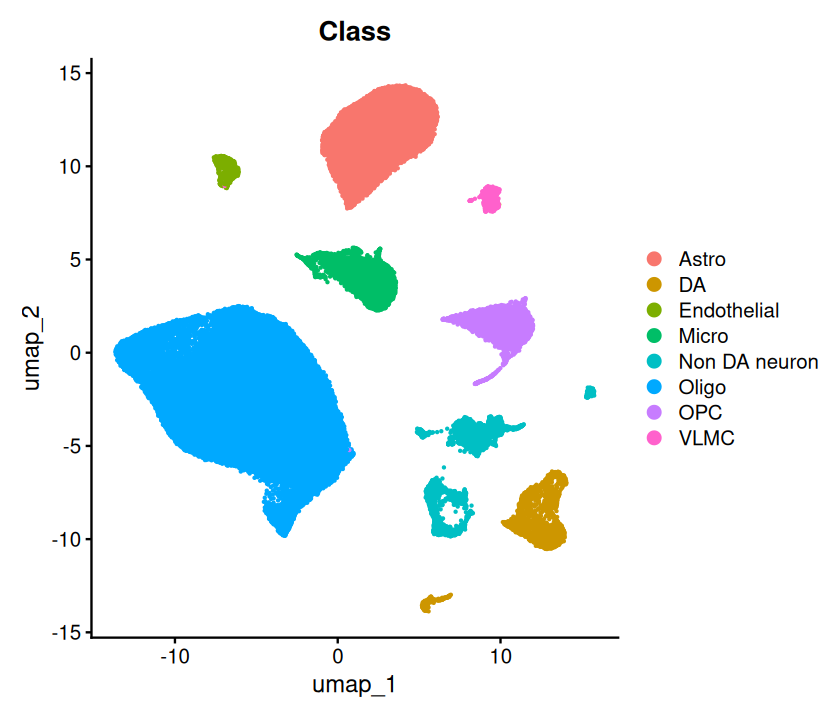

In [ ]:
options(repr.plot.width=7, repr.plot.height=6)
DimPlot(SCTseurat_harmony_1, group.by = "Class" )

In [ ]:
pdf(file = "/mnt/90-connectome/Personal/CQW/midbrain/figure/VTA_class_umap.pdf", width = 7, height = 6)

options(repr.plot.width=7, repr.plot.height=6)
DimPlot(SCTseurat_harmony_1, group.by = "Class" )

dev.off()

agg_record_2100801312 
                    2

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


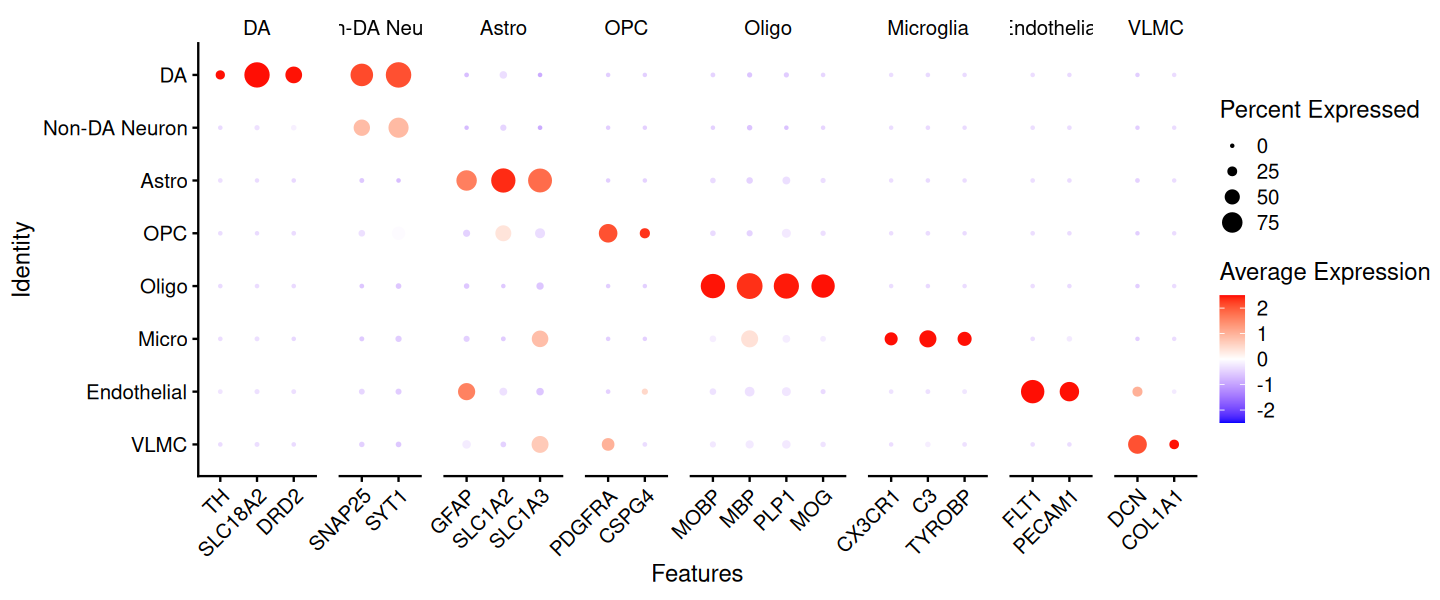

In [ ]:
# SCTseurat_harmony_1$Class = SCTseurat_harmony_1$maxPredClass

Non= c('SNAP25', 'SYT1')
DA= c('TH',  'SLC18A2', 'DRD2')
# GABA= c('GAD1', 'GAD2', 'SLC32A1')
# Glut= c('SLC17A6', 'SLC17A7', 'SLC17A8')
Astro= c( 'GFAP', 'SLC1A2', 'SLC1A3')
Oligo= c('MOBP', 'MBP', 'PLP1', 'MOG')
OPC= c('PDGFRA', 'CSPG4')
Micro= c('CX3CR1',  'C3', 'TYROBP')
Endothelial= c( 'FLT1', 'PECAM1')
VLMC= c('DCN', 'COL1A1')

options(repr.plot.height=5,repr.plot.width=12)
class_order = c(
    "VLMC", "Endothelial",
    # "GABA",
    # "Glut",
    "Micro",
    "Oligo",
    "OPC",
    "Astro",
    "Non-DA Neuron",
    "DA"
)
class_order = c(
    class_order[class_order %in% unique(as.character(SCTseurat_harmony_1$Class))],
    setdiff(unique(as.character(SCTseurat_harmony_1$Class)), class_order)
)
SCTseurat_harmony_1$Class = factor(as.character(SCTseurat_harmony_1$Class), levels = class_order)
Idents(SCTseurat_harmony_1) = "Class"
features <- list(
    "DA" = DA,
    "Non-DA Neuron" = Non,
    # "VTA_SNc_DA" = VTA_SNc_DA,
    # "GABA" = GABA,
    # "Glut" = Glut,
    "Astro" = Astro,
    "OPC" = OPC,
    "Oligo" = Oligo,
    "Microglia" = Micro,
    "Endothelial" = Endothelial,
    "VLMC" = VLMC
)
feature_order = c("DA", "Non-DA Neuron", "GABA", "Glut", "Astro", "OPC", "Oligo", "Microglia", "Endothelial", "VLMC")
features = features[feature_order[feature_order %in% names(features)]]
features = features[!duplicated(features)]

p_dotplot = DotPlot(SCTseurat_harmony_1, features = features, cluster.idents = FALSE) +
    RotatedAxis(45) +
    scale_color_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0, limits = c(-2.5, 2.5))

print(p_dotplot)
ggsave(
    filename = "/mnt/90-connectome/Personal/CQW/midbrain/figure/VTA_class_marker_dotplot.pdf",
    plot = p_dotplot,
    width = 12,
    height = 5,
    units = "in",
    device = cairo_pdf
)

Warning message:
“The `<scale>` argument of `guides()` cannot be `FALSE`. Use "none" instead as
of ggplot2 3.3.4.”


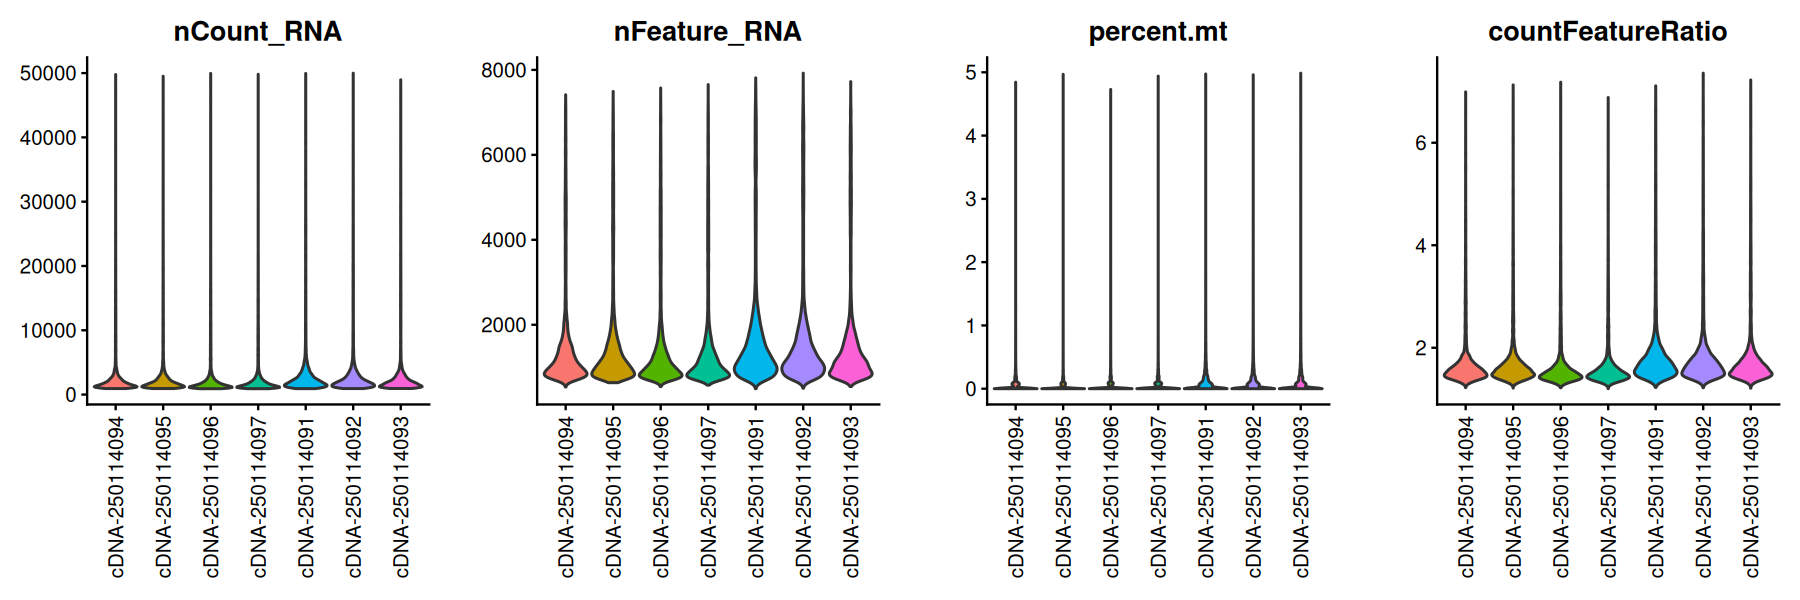

In [ ]:
Idents(SCTseurat_harmony_1) = "Library"
options(repr.plot.width=15, repr.plot.height=5)
print(plot_grid(
    plotlist = lapply(c("nCount_RNA", "nFeature_RNA", "percent.mt", "countFeatureRatio"), function(x) {
        p = VlnPlot(SCTseurat_harmony_1, features=x, pt.size=0) + 
            theme(axis.text.x=element_text(vjust=0.5, hjust=0.5, angle=90), axis.title.x = element_blank()) +
            guides(fill=FALSE)
        return(p)
    }), 
    ncol=4, align="hv", axis="tblr"
))

In [ ]:
table(SCTseurat_harmony_1$Animal)


Mq246 Mq277 
45837 35370 

In [ ]:
table(SCTseurat_harmony_1$cluster)


         Astro_0          Astro_1          Astro_2          Astro_3 
            5266             3852             3096              686 
         Astro_4          Astro_5          Astro_6             DA_0 
             420              239               40              670 
            DA_1             DA_2             DA_3             DA_4 
             620              549              465              420 
            DA_5             DA_6             DA_7    Endothelial_0 
             344              343              219              615 
         Micro_0          Micro_1  Non_DA_Neuron_0  Non_DA_Neuron_1 
            4679              266             1369             1082 
Non_DA_Neuron_10 Non_DA_Neuron_11 Non_DA_Neuron_12  Non_DA_Neuron_2 
             118               58               43              508 
 Non_DA_Neuron_3  Non_DA_Neuron_4  Non_DA_Neuron_5  Non_DA_Neuron_6 
             360              359              317              316 
 Non_DA_Neuron_7  Non_DA_Neuron_8

In [ ]:
length(unique(SCTseurat_harmony_1$cluster))

[1] 45

In [ ]:
Idents(SCTseurat_harmony_1) = "Class"
sub = subset(SCTseurat_harmony_1, downsample = 1000)
class_marker = FindAllMarkers(sub, only.pos = TRUE, logfc.threshold = 0.25, test.use = "MAST")


Calculating cluster VLMC

Warning message in new_with_repaired_slots(classname = method, design = colData(sca), :
“Dropping illegal slot(s) norm.method for class BayesGLMlike.  
                    This likely indicates a bug in an upstream package.”

Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!

Calculating cluster Endothelial

Warning message in new_with_repaired_slots(classname = method, design = colData(sca), :
“Dropping illegal slot(s) norm.method for class BayesGLMlike.  
                    This likely indicates a bug in an upstream package.”

Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!

Calculating cluster Micro

Warning message in new_with_repaired_slots(classname = method, design = colData(sca), :
“Dropping illegal slot(s) norm.method for class BayesGLMlike. 

In [43]:
write.csv(
    class_marker,
    "/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/class_marker.csv",
    row.names = TRUE
)

In [41]:
Idents(SCTseurat_harmony_1) = "cluster"
sub_cluster = subset(SCTseurat_harmony_1, downsample = 200)
cluster_marker = FindAllMarkers(sub_cluster, only.pos = TRUE, logfc.threshold = 0.25, test.use = "MAST")

Calculating cluster DA_3

Warning message in new_with_repaired_slots(classname = method, design = colData(sca), :
“Dropping illegal slot(s) norm.method for class BayesGLMlike.  
                    This likely indicates a bug in an upstream package.”

Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!

Calculating cluster DA_7

Warning message in new_with_repaired_slots(classname = method, design = colData(sca), :
“Dropping illegal slot(s) norm.method for class BayesGLMlike.  
                    This likely indicates a bug in an upstream package.”

Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!

Calculating cluster DA_0

Warning message in new_with_repaired_slots(classname = method, design = colData(sca), :
“Dropping illegal slot(s) norm.method for class BayesGLMlike.  
      

In [44]:
write.csv(
    cluster_marker,
    "/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/cluster_marker.csv",
    row.names = TRUE
)

In [51]:
metadata = SCTseurat_harmony_1@meta.data
write.csv(
    metadata,
    "/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/Macaque_VTA_dataset_Class_cluster_metadata.csv",
    row.names = TRUE
)

In [48]:
cols_to_remove <- c("class", "seurat_clusters","celltype")

SCTseurat_harmony_1@meta.data <- SCTseurat_harmony_1@meta.data %>%
    dplyr::select(-dplyr::any_of(cols_to_remove))

In [ ]:
saveRDS(SCTseurat_harmony_1, '/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/Macaque_VTA_dataset.rds')

In [ ]:
SCTseurat_harmony_1 = readRDS('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/Macaque_VTA_dataset.rds')